# From X search to a clean dataset — data centers in Argentina

This notebook walks through the whole collection pipeline, from the search query sent to X to the
clean table the analysis uses. It runs on a CSV export of `dc_tweets_raw` (or straight from Supabase)
and uses the **same** `config.py` and `filters.py` as the scraper, so what you see here is exactly
what runs every morning.

Two layers of filtering, on either side of the API call:

```
config.py ─► search query ─► X API ─► tweets returned ─► code rules ─► dc_tweets
             (section 1)      $$$      dc_tweets_raw       (section 3)   (section 4)
                                        (section 2)
```

* **Before the API** we narrow the query as much as we can, because that is the only place
  where filtering saves money. We can explain this layer but not demonstrate it: tweets the query
  excluded were never received.
* **After the API** we keep everything that came back and tag each row with the rule that
  rejected it (or none). That layer is fully reproducible, rule by rule, below.

In [1]:
import sys, json, os
from pathlib import Path
REPO = Path("..").resolve()            # notebook lives in notebooks/, code in the repo root
sys.path.insert(0, str(REPO))

import pandas as pd
import matplotlib.pyplot as plt
import config as C
import filters as F
import clean

pd.set_option("display.max_colwidth", 140)

## 1. Where we start: what we ask X for

Every query is `CORE_TERMS AND ARGENTINA_ANCHORS`: a tweet must mention a data center **and**
something that ties it to Argentina. Company names (`COMPANY_ANCHORS`) are never used alone.
`-filter:nativeretweets` drops plain retweets before we pay for them.

In [2]:
from scrape import build_queries
for i, q in enumerate(build_queries()):
    print(f"[{i}] ({len(q)} chars)\n    {q}\n")

[0] (424 chars)
    ("data center" OR "data centers" OR datacenter OR datacenters OR "centro de datos" OR "centros de datos" OR "centro de cómputo") (Argentina OR argentino OR argentina OR argentinos OR Patagonia OR "Río Negro" OR "Rio Negro" OR "Sierra Grande" OR "Bahía Blanca" OR "Buenos Aires" OR Córdoba OR Mendoza OR Neuquén OR "Vaca Muerta" OR Añelo OR RIGI OR "Secretaría de Energía" OR CAMMESA OR ENARSA) lang:es -filter:nativeretweets

[1] (333 chars)
    ("data center" OR "data centers" OR datacenter OR datacenters OR "centro de datos" OR "centros de datos" OR "centro de cómputo") (OpenAI OR Altman OR Microsoft OR Google OR AWS OR Amazon OR Meta OR Nvidia OR Oracle OR Cirion OR Telecom OR Claro OR Equinix) (Argentina OR argentino OR Patagonia OR RIGI) lang:es -filter:nativeretweets

[2] (197 chars)
    ("data center" OR "data centers" OR datacenter OR datacenters OR "centro de datos" OR "centros de datos" OR "centro de cómputo") (Argentina OR Argentine OR Patagonia) lang:en -fil

**Why the anchors matter.** The scraper has a `test` mode (~$0.015). Running `CORE_TERMS` alone
for one week returns mostly US and Chinese data-center news; with the Argentina anchor the same
week returns a few dozen on-topic posts. That one experiment is the justification for pre-filtering.

**What we paid.** Every run records what it fetched and its estimated cost in `dc_runs`.

In [3]:
# Optional: export dc_runs to data/dc_runs.csv (Supabase → Table editor → Export) to see the ledger.
runs_path = REPO / "data" / "dc_runs.csv"
if runs_path.exists():
    runs = pd.read_csv(runs_path, parse_dates=["started_at", "finished_at"])
    print(f"{len(runs)} runs | fetched {runs['fetched'].sum():,} tweets | est. cost ${runs['est_cost_usd'].sum():.2f}")
    display(runs[["run_mode", "started_at", "fetched", "inserted", "est_cost_usd"]].tail(10))
else:
    print("no data/dc_runs.csv — skip")

no data/dc_runs.csv — skip


## 2. What arrived: the raw table

`dc_tweets_raw` holds every tweet the API returned. `drop_reason` is `NaN` for the rows that passed
all rules and the rule name otherwise. Rows with `legacy = True` were collected before the raw
table existed: they passed the rules in force at the time, and their rejected siblings were not
stored (only their counts, in `dc_runs.notes`).

In [4]:
RAW_CSV = REPO / "data" / "dc_tweets_raw.csv"   # export of dc_tweets_raw, or the scraper's out/*.csv
if RAW_CSV.exists():
    rows = clean.load_raw_csv(str(RAW_CSV))
else:                                            # no export yet: use the synthetic sample
    rows = clean.load_raw_csv(str(REPO / "notebooks" / "sample_raw.csv"))
    print("using notebooks/sample_raw.csv (13 synthetic tweets)")

raw = pd.DataFrame(rows)
print(f"{len(raw):,} rows in the raw table")
raw["drop_reason"].fillna("kept").value_counts()

using notebooks/sample_raw.csv (13 synthetic tweets)
13 rows in the raw table


drop_reason
kept        6
bot         3
retweet     1
short       1
offtopic    1
dup_text    1
Name: count, dtype: int64

## 3. What we remove, rule by rule

All rules are functions in `filters.py`; all thresholds are in `config.py`. Below, each rule gets
a short explanation, the setting that controls it, and real examples it rejected.

In [5]:
# Re-run every rule on the raw rows (this is exactly what clean.py does).
verdicts = pd.DataFrame(clean.apply_rules(rows))
df = raw.drop(columns=["drop_reason", "source_type", "outlet_handle"], errors="ignore").merge(verdicts, on="tweet_id")
df["verdict"] = df["drop_reason"].fillna("kept")

def examples(reason, n=3):
    cols = ["author_username", "text"]
    return df.loc[df["drop_reason"] == reason, cols].head(n)

### 3.1 Retweets
A retweet repeats someone else's words; it is not a new opinion. Most are removed by the query
(`-filter:nativeretweets`); the ones the API still returns carry a `retweeted_tweet` object.

In [6]:
examples("retweet")

,author_username,text
1,juan_perez,RT @infobae: Nuevo data center en Argentina


### 3.2 Bots and spam accounts — `C.BOT_RULES`
Dropped if the author trips any of: X's own *Automated* label, a username pattern
(`bot`, `_ai`, `digest`, `news24`…), more than `max_statuses_per_day` posts per day over the
account's lifetime, or an account younger than `min_account_age_days`.

In [7]:
print(json.dumps(C.BOT_RULES, indent=2))
df.loc[df["drop_reason"] == "bot"].assign(rule=lambda d: d["raw"].map(lambda r: F.is_bot(clean.tweet_dict({"raw": r}).get("author", {})))) \
  [["author_username", "rule", "author_statuses", "author_created_at", "text"]].head(5)

{
  "drop_if_automated_flag": true,
  "drop_if_username_matches": "(?i)(bot|_ia$|_ai$|ainew|noticias24|news24|digest|podcast_|summary)",
  "max_statuses_per_day": 150,
  "min_account_age_days": 14,
  "drop_if_no_text_after_mentions": true,
  "min_text_chars": 25
}


,author_username,rule,author_statuses,author_created_at,text
2,noticias24_bot,username_pattern,2000,2023-01-02T10:00:00+00:00,Data center en Bahía Blanca: gran noticia para Argentina
3,juan_perez,account_too_new,2000,2026-09-29T10:00:00+00:00,Centro de datos en Córdoba sería un cambio total para el RIGI
4,juan_perez,posting_rate,900000,2023-01-02T10:00:00+00:00,Centro de datos en Córdoba sería un cambio total para el RIGI


### 3.3 Too short — `min_text_chars`
After removing leading @mentions and links, anything under 25 characters ("buenísimo", "jaja") has
no opinion to score.

In [8]:
examples("short")

,author_username,text
5,juan_perez,@infobae buenísimo


### 3.4 Off topic — `TOPIC_RE`, `ARGENTINA_RE`, `ARGENTINA_FALSE_RE`
The query matches anywhere in a post, so a 2,000-character digest that says *data centers* once and
*Argentina* once in another paragraph gets through. A tweet passes only if:

1. a data-center term **and** an Argentina term both appear (quoted tweet text counts), and
2. the Argentina term is not inside a *false* phrase (*than Argentina*, *carne argentina*,
   *Messi*, *Mundial*), and
3. for texts over `LONG_TEXT_CHARS` (600), the two terms sit within `PROXIMITY_CHARS` (200) of
   each other. Outlet accounts are exempt from (3).

In [9]:
print("TOPIC_RE      =", C.TOPIC_RE)
print("ARGENTINA_RE  =", C.ARGENTINA_RE[:120], "…")
print("FALSE phrases =", C.ARGENTINA_FALSE_RE)
examples("offtopic")

TOPIC_RE      = data\s?-?cent(?:er|re)s?|datacenters?|centros?\s+de\s+(?:datos|c[oó]mputo)|#centrosdedatos
ARGENTINA_RE  = argentin|patagoni|r[ií]o\s+negro|sierra\s+grande|bah[ií]a\s+blanca|buenos\s+aires|c[oó]rdoba|mendoza|neuqu[eé]n|vaca\s+m …
FALSE phrases = than\s+argentina|beef\s+from\s+argentina|argentin\w*\s+beef|carne\s+argentina|argentina\s+(?:vs|v\.?)\s|messi|mundial|world\s+cup


,author_username,text
6,juan_perez,"Data centers use more power than Argentina as a whole, says new report"
7,juan_perez,El informe resalta que el data center consume mucho más de lo previsto


**Live check.** Edit the sentences to see what each regex picks up. This is also where the
weaknesses show: before the `\bsalta\b` fix, *resalta* counted as the province.

In [10]:
tests = [
    "El data center de OpenAI en la Patagonia va a necesitar 500 MW",
    "Data centers use more power than Argentina as a whole",
    "El informe resalta que el data center consume mucho",
    "Nuevo centro de datos en Córdoba, España",
]
pd.DataFrame({"text": tests,
              "topic": [F.topic_matches(t) for t in tests],
              "argentina": [F.argentina_matches(t) for t in tests],
              "on_topic": [F.is_on_topic(t) for t in tests]})

,text,topic,argentina,on_topic
0,El data center de OpenAI en la Patagonia va a necesitar 500 MW,[data center],[Patagoni],True
1,Data centers use more power than Argentina as a whole,[Data centers],[],False
2,El informe resalta que el data center consume mucho,[data center],[],False
3,"Nuevo centro de datos en Córdoba, España",[centro de datos],[Córdoba],True


### 3.5 Near-duplicates
Copy-paste reposts by different accounts collapse on the first 200 characters of normalised text.
The first occurrence is kept.

In [11]:
examples("dup_text")

,author_username,text
8,otra_cuenta,El data center de OpenAI en la Patagonia va a necesitar 500 MW de energía. ¿Quién paga eso?


### 3.6 The funnel

,step,remaining,dropped
0,fetched (dc_tweets_raw),13,NaN
1,− retweet,12,1.0
2,− bot,9,3.0
3,− short,8,1.0
4,− offtopic,6,2.0
5,− dup_text,5,1.0


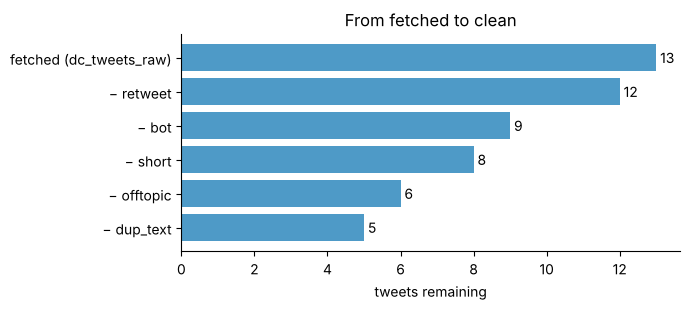

In [12]:
summary = clean.funnel(rows, clean.apply_rules(rows))
fun = pd.DataFrame(summary["funnel"])
display(fun)

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.barh(fun["step"][::-1], fun["remaining"][::-1], color="#4E9AC7")
for y, v in enumerate(fun["remaining"][::-1]):
    ax.text(v, y, f" {v:,}", va="center")
ax.set_xlabel("tweets remaining"); ax.set_title("From fetched to clean")
for s in ("top", "right"): ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

**Before the raw table existed** the rejects were not stored, but every run kept its counts. If
`data/dc_runs.csv` is present, this rebuilds the historical funnel from `notes.dropped`.

In [13]:
if runs_path.exists():
    notes = runs["notes"].dropna().map(json.loads)
    hist = pd.DataFrame([n.get("dropped", {}) for n in notes]).sum().astype(int)
    hist["fetched"] = int(runs["fetched"].sum()); hist["inserted"] = int(runs["inserted"].sum())
    display(hist.to_frame("count"))

## 4. Who is speaking: segments

`filters.classify()` tags each surviving tweet by its relation to the news. Outlet posts are
information, not opinion, and are excluded from sentiment scoring (`C.OPINION_TYPES`).

In [14]:
seg = pd.DataFrame({"segment": C.SOURCE_TYPES.keys(), "meaning": C.SOURCE_TYPES.values()})
seg["n_clean"] = seg["segment"].map(df.loc[df["drop_reason"].isna(), "source_type"].value_counts()).fillna(0).astype(int)
seg

,segment,meaning,n_clean
0,outlet_post,"headline post of a news outlet or official account — information, not opinion",1
1,news_reply,direct reply to an outlet's post,1
2,news_quote,quote-repost of an outlet's post with the person's own comment,0
3,news_thread,"reply inside an outlet's thread, addressed to another commenter",1
4,verified_opinion,"standalone post by a verified account with ≥ 2,000 followers",1
5,general_public,everyone else,1


## 5. Next: text preparation and TF-IDF

The clean rows (`drop_reason` is null) are the input to the lemmatisation / TF-IDF step that
produces `tf_terms.csv` and `tfidf_by_segment.csv` for the Streamlit app. Paste that code here.
`pipeline_summary.json` (written by `clean.py`) carries the funnel, segment counts and thresholds,
so the app's method text can be generated from it instead of copied by hand.

In [15]:
clean_df = df[df["drop_reason"].isna()].copy()
print(f"{len(clean_df):,} clean rows | languages: {clean_df['lang'].value_counts().to_dict()}")
# clean_df[clean_df["lang"] == "es"] → TF-IDF

5 clean rows | languages: {'es': 5}
